1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

2. Load Data

In [2]:
# Load the data
df_fraud = pd.read_csv('../data/raw/Fraud_Data.csv')

# Display basic info
print("Dataset Shape:", df_fraud.shape)
print("\nFirst 5 rows:")
df_fraud.head()

Dataset Shape: (151112, 11)

First 5 rows:


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


3. Data Overview

In [3]:
# Check data types
print("Data Types:")
print(df_fraud.dtypes)
print("\n" + "="*50)

# Check for missing values
print("\nMissing Values:")
print(df_fraud.isnull().sum())

# Check for duplicates
print("\nDuplicate Rows:", df_fraud.duplicated().sum())

Data Types:
user_id             int64
signup_time           str
purchase_time         str
purchase_value      int64
device_id             str
source                str
browser               str
sex                   str
age                 int64
ip_address        float64
class               int64
dtype: object


Missing Values:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Duplicate Rows: 0


4. Convert Date Columns

In [4]:
# Convert to datetime
df_fraud['signup_time'] = pd.to_datetime(df_fraud['signup_time'])
df_fraud['purchase_time'] = pd.to_datetime(df_fraud['purchase_time'])

# Verify conversion
print(df_fraud[['signup_time', 'purchase_time']].dtypes)
print("\nDate range:")
print(f"Signup: {df_fraud['signup_time'].min()} to {df_fraud['signup_time'].max()}")
print(f"Purchase: {df_fraud['purchase_time'].min()} to {df_fraud['purchase_time'].max()}")

signup_time      datetime64[us]
purchase_time    datetime64[us]
dtype: object

Date range:
Signup: 2015-01-01 00:00:42 to 2015-08-18 04:40:29
Purchase: 2015-01-01 00:00:44 to 2015-12-16 02:56:05


5. Target Variables Analysis

Class Distribution:
Legitimate (0): 136,961 (90.64%)
Fraud (1): 14,151 (9.36%)


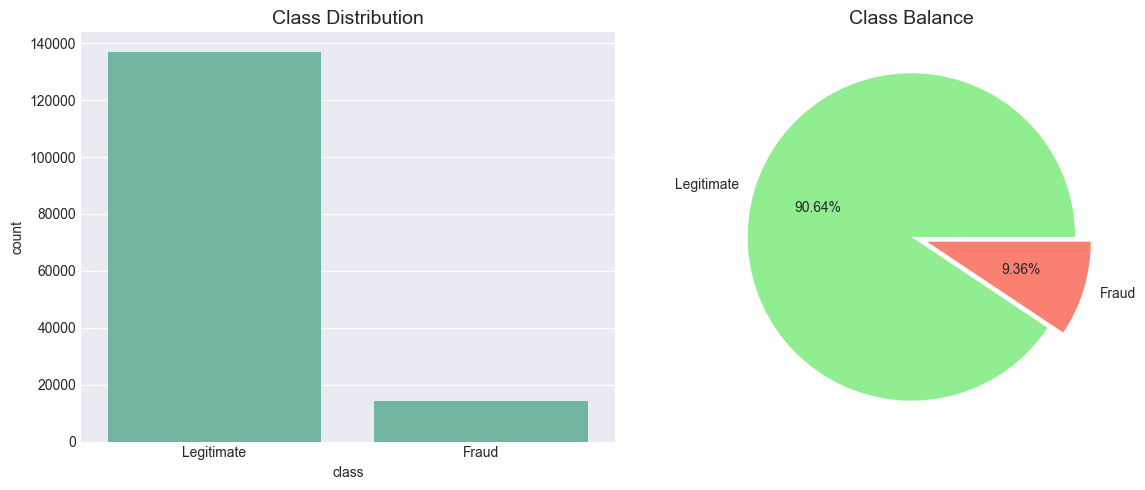

In [5]:
# Check class imbalance
fraud_counts = df_fraud['class'].value_counts()
fraud_percent = df_fraud['class'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"Legitimate (0): {fraud_counts[0]:,} ({fraud_percent[0]:.2f}%)")
print(f"Fraud (1): {fraud_counts[1]:,} ({fraud_percent[1]:.2f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df_fraud, x='class', ax=axes[0])
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_xticklabels(['Legitimate', 'Fraud'])

# Pie chart
axes[1].pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%', 
            colors=['lightgreen', 'salmon'], explode=(0, 0.1))
axes[1].set_title('Class Balance', fontsize=14)

plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=100)
plt.show()

6. Numerical Variables Analysis

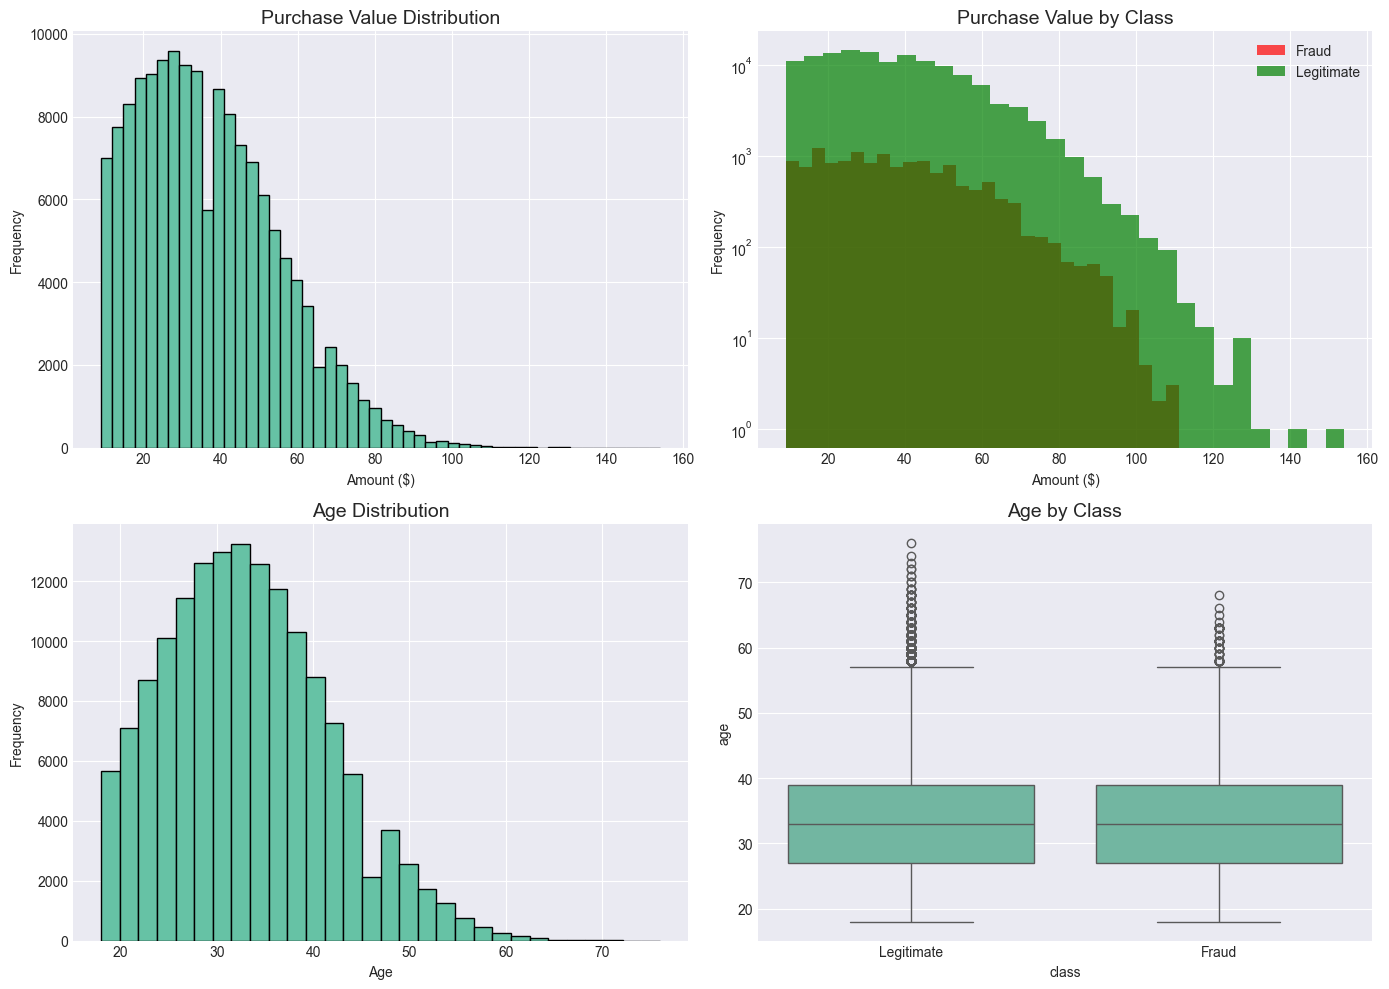


Purchase Value Statistics by Class:
          count       mean        std  min   25%   50%   75%    max
class                                                              
0      136961.0  36.929418  18.315064  9.0  22.0  35.0  49.0  154.0
1       14151.0  36.993004  18.397654  9.0  22.0  35.0  49.0  111.0


In [6]:
# Analyze purchase_value
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Purchase value distribution
axes[0,0].hist(df_fraud['purchase_value'], bins=50, edgecolor='black')
axes[0,0].set_title('Purchase Value Distribution', fontsize=14)
axes[0,0].set_xlabel('Amount ($)')
axes[0,0].set_ylabel('Frequency')

# Purchase value by class (log scale)
fraud_data = df_fraud[df_fraud['class']==1]['purchase_value']
legit_data = df_fraud[df_fraud['class']==0]['purchase_value']

axes[0,1].hist(fraud_data, bins=30, alpha=0.7, label='Fraud', color='red')
axes[0,1].hist(legit_data, bins=30, alpha=0.7, label='Legitimate', color='green')
axes[0,1].set_title('Purchase Value by Class', fontsize=14)
axes[0,1].set_xlabel('Amount ($)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()
axes[0,1].set_yscale('log')

# Age distribution
axes[1,0].hist(df_fraud['age'], bins=30, edgecolor='black')
axes[1,0].set_title('Age Distribution', fontsize=14)
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Frequency')

# Age by class
sns.boxplot(data=df_fraud, x='class', y='age', ax=axes[1,1])
axes[1,1].set_title('Age by Class', fontsize=14)
axes[1,1].set_xticklabels(['Legitimate', 'Fraud'])

plt.tight_layout()
plt.savefig('../data/processed/numerical_analysis.png', dpi=100)
plt.show()

# Summary statistics
print("\nPurchase Value Statistics by Class:")
print(df_fraud.groupby('class')['purchase_value'].describe())

7. Categorical Variables Analysis

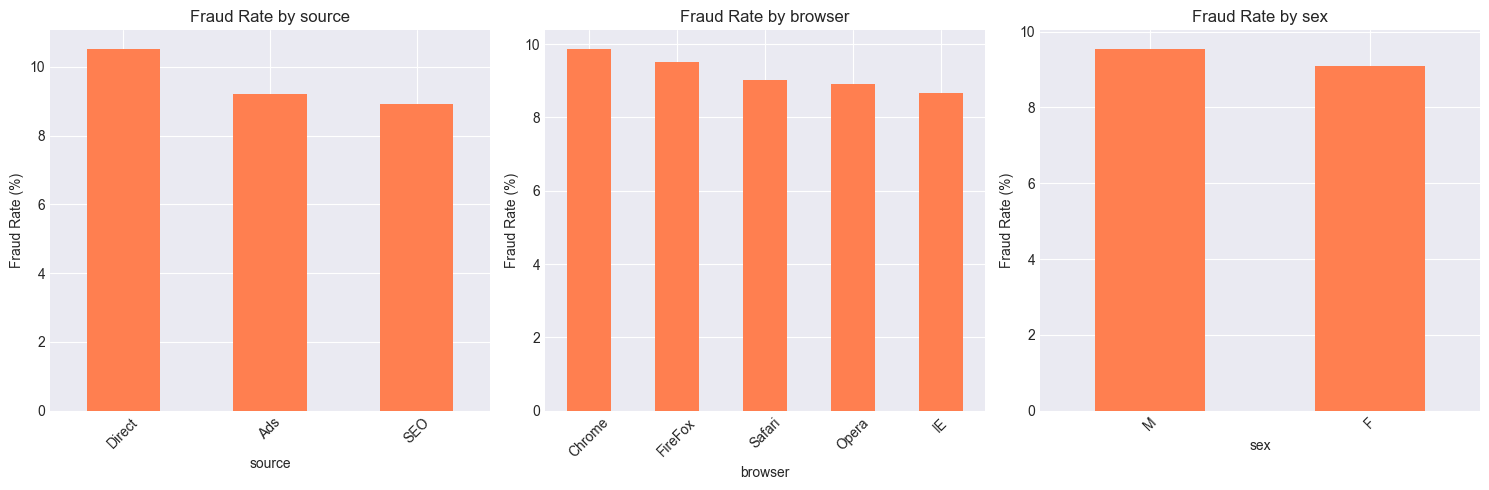


Fraud Rate by source:
source
Direct    10.536974
Ads        9.206593
SEO        8.928483
Name: class, dtype: float64

Fraud Rate by browser:
browser
Chrome     9.879216
FireFox    9.516457
Safari     9.020148
Opera      8.922742
IE         8.677540
Name: class, dtype: float64

Fraud Rate by sex:
sex
M    9.552286
F    9.100750
Name: class, dtype: float64


In [7]:
# Analyze categorical variables
categorical_cols = ['source', 'browser', 'sex']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(categorical_cols):
    # Get fraud rate per category
    fraud_rate = df_fraud.groupby(col)['class'].mean() * 100
    fraud_rate.sort_values(ascending=False, inplace=True)
    
    fraud_rate.plot(kind='bar', ax=axes[idx], color='coral')
    axes[idx].set_title(f'Fraud Rate by {col}', fontsize=12)
    axes[idx].set_ylabel('Fraud Rate (%)')
    axes[idx].set_xlabel(col)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/categorical_analysis.png', dpi=100)
plt.show()

# Print fraud rates
for col in categorical_cols:
    print(f"\nFraud Rate by {col}:")
    print(df_fraud.groupby(col)['class'].mean().sort_values(ascending=False) * 100)

8. Temporal Patterns

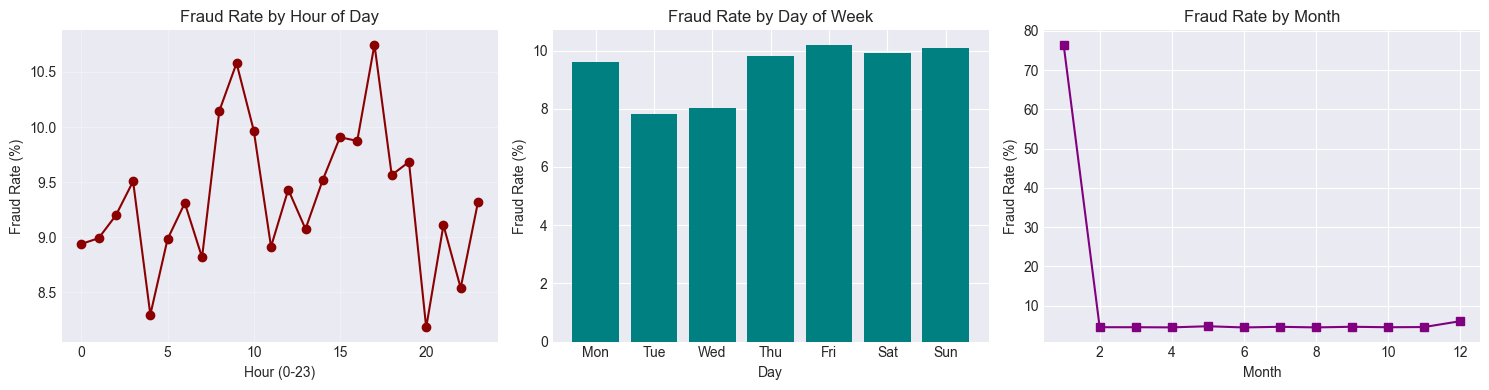

In [8]:
# Extract time features
df_fraud['hour'] = df_fraud['purchase_time'].dt.hour
df_fraud['day_of_week'] = df_fraud['purchase_time'].dt.dayofweek
df_fraud['month'] = df_fraud['purchase_time'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Hour of day
hourly_fraud = df_fraud.groupby('hour')['class'].mean() * 100
axes[0].plot(hourly_fraud.index, hourly_fraud.values, marker='o', color='darkred')
axes[0].set_title('Fraud Rate by Hour of Day', fontsize=12)
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].grid(True, alpha=0.3)

# Day of week
dow_fraud = df_fraud.groupby('day_of_week')['class'].mean() * 100
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(days, dow_fraud.values, color='teal')
axes[1].set_title('Fraud Rate by Day of Week', fontsize=12)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud Rate (%)')

# Monthly trend
monthly_fraud = df_fraud.groupby('month')['class'].mean() * 100
axes[2].plot(monthly_fraud.index, monthly_fraud.values, marker='s', color='purple')
axes[2].set_title('Fraud Rate by Month', fontsize=12)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('../data/processed/temporal_patterns.png', dpi=100)
plt.show()

9. Save Cleaned Data

In [9]:
# Save the cleaned data for next steps
df_fraud.to_csv('../data/processed/fraud_data_cleaned.csv', index=False)
print("Cleaned data saved to ../data/processed/fraud_data_cleaned.csv")

Cleaned data saved to ../data/processed/fraud_data_cleaned.csv
